In [1]:
import numpy as np
import pandas as pd
import os
import textwrap

In [2]:
def load_data(data_dir, x_filename='x_train.csv', y_filename='y_train.csv'):
    x_train_df = pd.read_csv(os.path.join(data_dir, x_filename))
    y_train_df = pd.read_csv(os.path.join(data_dir, y_filename))

    N, n_cols = x_train_df.shape
    print("Shape of x_train_df: (%d, %d)" % (N, n_cols))
    print("Shape of y_train_df: %s" % str(y_train_df.shape))

    # Print out 8 random entries
    tr_text_list = x_train_df['text'].values.tolist()
    prng = np.random.RandomState(101)
    rows = prng.permutation(np.arange(y_train_df.shape[0]))
    for row_id in rows[:3]:
        text = tr_text_list[row_id]
        print("row %5d | %s BY %s | y = %s" % (
            row_id,
            y_train_df['title'].values[row_id],
            y_train_df['author'].values[row_id],
            y_train_df['Coarse Label'].values[row_id],
            ))
        # Pretty print text via textwrap library
        line_list = textwrap.wrap(tr_text_list[row_id],
            width=70,
            initial_indent='  ',
            subsequent_indent='  ')
        print('\n'.join(line_list))
        print("")
    return x_train_df, y_train_df

In [3]:
x_train_df, y_train_df = load_data(data_dir = "data", x_filename = "x_train.csv", y_filename = "y_train.csv")

Shape of x_train_df: (5557, 32)
Shape of y_train_df: (5557, 5)
row  4746 | The Red and the Black: A Chronicle of 1830 BY Stendhal | y = Key Stage 4-5
  It was hermetically sealed; he was on the point of  fainting and
  remained for a long time leaning against the oak; then  with a
  staggering step he went to have another look at the gardener's
  ladder. The chain which he had once forced asunder--in, alas, such
  different  circumstances--had not yet been repaired. Carried away by
  a moment of  madness, Julien pressed it to his lips.

row  1250 | Cranford BY Elizabeth Cleghorn Gaskell | y = Key Stage 4-5
  Miss Pole, Miss Matty, and I, meanwhile attended to Miss Brown: and
  hard  work we found it to relieve her querulous and never-ending
  complaints. But if we were so weary and dispirited, what must Miss
  Jessie have been! Yet she came back almost calm as if she had gained
  a new strength. She  put off her mourning dress, and came in,
  looking pale and gentle,  thanking us each 

In [4]:
import sklearn

In [5]:
def make_logit_pipeline(C=1.0):
    steps = [('logit', sklearn.linear_model.LogisticRegression(solver="lbfgs", l1_ratio=0, C=C, max_iter=1000))]
    pipeline = sklearn.pipeline.Pipeline(steps=steps)
    return pipeline

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [7]:
def find_best_vocab(
    x_df=x_train_df, 
    y_labels=y_train_df['Coarse Label'], 
    min_df_range=range(10, 51, 5), 
    max_df_range=np.arange(1.0, 0.45, -.05), 
    n_splits=10, 
    random_state=42
):
    hypers_list = []
    kf = sklearn.model_selection.KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    for min_df in min_df_range:
        for max_df in max_df_range:
            # Build feature matrix for this vocab
            # Use TfidfVectorizer to build count matrix; TF-IDF will be applied in the pipeline
            vectorizer = TfidfVectorizer(min_df=min_df, max_df=max_df)
            X_train = vectorizer.fit_transform(x_df['text'])
            vocab = vectorizer.get_feature_names_out()
            X_counts = X_train.toarray()
            vocab_df = pd.DataFrame(X_counts, columns=vocab, index=x_df.index)
            
            # CV evaluation with this vocab
            pl = make_logit_pipeline(C=1.0)
            aucs = []
            for train_index, val_index in kf.split(vocab_df):
                x_train_fold = vocab_df.iloc[train_index]
                y_train_fold = y_labels.iloc[train_index]
                x_val_fold = vocab_df.iloc[val_index]
                y_val_fold = y_labels.iloc[val_index]
                
                pl.fit(x_train_fold, y_train_fold)
                y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]
                auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
                aucs.append(auc)
            
            mean_auc = np.mean(aucs)
            hypers_list.append((min_df, max_df, len(vocab), mean_auc))
    
    # Get best vocab bounds
    best_hypers_config = max(hypers_list, key=lambda x: x[3])
    best_min_df, best_max_df, best_vocab_length, best_auc = best_hypers_config
    
    return {
        'best_min_df': best_min_df,
        'best_max_df': best_max_df,
        'best_vocab_length': best_vocab_length,
        'best_auc': best_auc
    }

In [8]:
# Run tuning
results = find_best_vocab()
best_min_df = results['best_min_df']
best_max_df = results['best_max_df']

print(f"\n✓ Best bounds: min={best_min_df}, max={best_max_df}")
print(f"  Vocab size: {results['best_vocab_length']}")
print(f"  Best AUC: {results['best_auc']:.4f}")


✓ Best bounds: min=10, max=0.95
  Vocab size: 3515
  Best AUC: 0.7963


In [9]:
# Load and augment test data with same vocabulary
x_test_df = pd.read_csv(os.path.join("data", "x_test.csv"))

vectorizer = TfidfVectorizer(min_df=best_min_df, max_df=best_max_df)
X_train_counts = vectorizer.fit_transform(x_train_df['text']).toarray()
analyze = vectorizer.build_analyzer()
vocab = vectorizer.get_feature_names_out()
print(vocab[:5])
print("X train counts:")
print(X_train_counts[:5])
X_test_counts = vectorizer.transform(x_test_df['text']).toarray()
print("X test counts: ")
print(X_test_counts[:5])

x_train_df_new = pd.DataFrame(X_train_counts, columns=vocab, index=x_train_df.index)
x_test_df_new = pd.DataFrame(X_test_counts, columns=vocab, index=x_test_df.index)

['15' '_i_' '_the' '_you_' 'abandoned']
X train counts:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
X test counts: 
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [10]:
best_pl = make_logit_pipeline(C=1.0)
best_pl.fit(x_train_df_new, y_train_df['Coarse Label'])
y_test_pred_proba = best_pl.predict_proba(x_test_df_new)[:, 1]
with open("yproba1_test_p2.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")

In [11]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set_theme('notebook', style='whitegrid', font_scale=1.25)

AUC of: 0.7366450924185529 for C of: 0.0001
AUC of: 0.736752144431432 for C of: 0.00031622776601683794
AUC of: 0.7370163625036331 for C of: 0.001
AUC of: 0.7377927336589069 for C of: 0.0031622776601683794
AUC of: 0.7400235128953595 for C of: 0.01
AUC of: 0.745651768832862 for C of: 0.03162277660168379
AUC of: 0.7598531954357913 for C of: 0.1
AUC of: 0.7789017479937289 for C of: 0.31622776601683794
AUC of: 0.7963337020633349 for C of: 1.0
AUC of: 0.8040600729227162 for C of: 3.1622776601683795
AUC of: 0.799523143726148 for C of: 10.0
AUC of: 0.7871482005211575 for C of: 31.622776601683793
AUC of: 0.7759514361781188 for C of: 100.0
AUC of: 0.7765552377239622 for C of: 316.22776601683796
AUC of: 0.7785194087095342 for C of: 1000.0
AUC of: 0.7790399908362545 for C of: 3162.2776601683795
AUC of: 0.7785445469685272 for C of: 10000.0
Best C: 3.1622776601683795, Best AUC: 0.8040600729227162


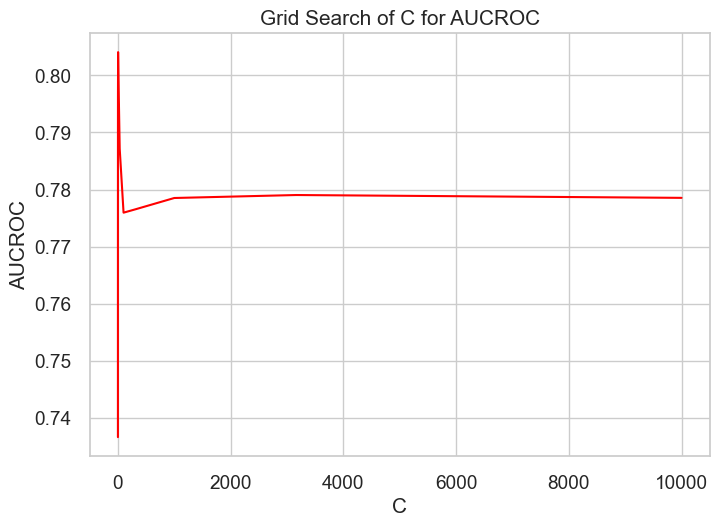

In [12]:
C_grid = np.logspace(-4, 4, 17)
hypers_list = []

kf = sklearn.model_selection.KFold(n_splits=10, shuffle=True, random_state=42)
for C in C_grid:
  pl = make_logit_pipeline(C=C)
  aucs = []
  for train_index, val_index in kf.split(x_train_df_new):
    x_train_fold = x_train_df_new.iloc[train_index]
    y_train_fold = y_train_df['Coarse Label'].iloc[train_index]
    x_val_fold = x_train_df_new.iloc[val_index]
    y_val_fold = y_train_df['Coarse Label'].iloc[val_index]

    pl.fit(x_train_fold, y_train_fold)
    y_pred_proba = pl.predict_proba(x_val_fold)[:, 1]

    auc = sklearn.metrics.roc_auc_score(y_val_fold, y_pred_proba)
    aucs.append(auc)
  mean_auc = np.mean(aucs)
  hypers_list.append((C, mean_auc))

AUC_vals = [h[1] for h in hypers_list]
for C, AUC in zip(C_grid, AUC_vals):
    print(f"AUC of: {AUC} for C of: {C}")
plt.plot(C_grid, AUC_vals, color='red')
plt.xlabel('C')
plt.ylabel('AUCROC')
plt.title('Grid Search of C for AUCROC')

best_C, best_auc = max(hypers_list, key=lambda x: x[1])
print(f"Best C: {best_C}, Best AUC: {best_auc}")

In [13]:
best_pl = make_logit_pipeline(C=best_C)
best_pl.fit(x_train_df_new, y_train_df['Coarse Label'])
y_test_pred_proba = best_pl.predict_proba(x_test_df_new)[:, 1]
with open("yproba1_test_p2_best_C.txt", "w") as f:
    for pred in y_test_pred_proba:
        f.write(f"{pred}\n")